# 05 — Calibration

Calibration of baseline models using isotonic and Platt scaling, followed by test‑set evaluation and saving of metrics and calibration curves.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

from src.calibration import manual_calibration, predict_calibrated, metrics_from_probs
from src.visualization import plot_calibration_curves

In [2]:
# Load dataset
df = pd.read_csv("../data/processed/final_migraine.csv")
df.shape

(4152, 26)

In [3]:
# Load data
X_tr_prep = pd.read_csv("../data/processed/X_tr_prep.csv").values
X_te_prep = pd.read_csv("../data/processed/X_te_prep.csv").values

y_tr = pd.read_csv("../data/processed/y_tr.csv")["target"].values
y_te = pd.read_csv("../data/processed/y_te.csv")["target"].values

groups = pd.read_csv("../data/processed/train_ids.csv")["id"].values

In [4]:
# Load baseline models
models = {
    "Logistic Regression": joblib.load("../models/logistic_regression.pkl"),
    "Gradient Boosting": joblib.load("../models/gradient_boosting.pkl"),
    "XGBoost": joblib.load("../models/xgboost.pkl")
}

In [5]:
# Calibrate models (Isotonic and Platt scaling)
calibrated_models = {}

for name, model in models.items():
    print(f"Calibrating {name}...")
    _, cal_iso = manual_calibration(model, X_tr_prep, y_tr, groups, method="isotonic")
    _, cal_platt = manual_calibration(model, X_tr_prep, y_tr, groups, method="platt")
    calibrated_models[name] = {"Isotonic": cal_iso, "Platt": cal_platt}

Calibrating Logistic Regression...
Calibrating Gradient Boosting...
Calibrating XGBoost...


In [6]:
# Evaluate calibrated models
results_all = {}

for name, calibs in calibrated_models.items():
    for method, calibrator in calibs.items():
        y_pred = predict_calibrated(models[name], calibrator, X_te_prep)
        results_all[f"{name} ({method})"] = metrics_from_probs(y_te, y_pred)

for name, calibs in calibrated_models.items():
    for method, calibrator in calibs.items():
        filename = f"../models/{name.replace(' ', '_').lower()}_{method.lower()}.pkl"
        joblib.dump(calibrator, filename)
    
df_cal = pd.DataFrame(results_all).T
df_cal.to_csv("../reports/tables/calibration_metrics.csv")
df_cal

,ROC-AUC,PR-AUC,Brier,ECE,TP,TN,FP,FN,Precision,Sensitivity
Logistic Regression (Isotonic),0.705663,0.739182,0.212776,0.060133,426.0,168.0,187.0,98.0,0.694943,0.812977
Logistic Regression (Platt),0.625573,0.664778,0.331058,0.088737,446.0,142.0,213.0,78.0,0.676783,0.851145
Gradient Boosting (Isotonic),0.664891,0.708241,0.221823,0.025976,439.0,134.0,221.0,85.0,0.665152,0.837786
Gradient Boosting (Platt),0.606626,0.653417,0.350398,0.101251,435.0,136.0,219.0,89.0,0.665138,0.830153
XGBoost (Isotonic),0.650876,0.698764,0.226520,0.048631,406.0,148.0,207.0,118.0,0.662316,0.774809
XGBoost (Platt),0.604172,0.652053,0.354949,0.109215,428.0,139.0,216.0,96.0,0.664596,0.816794


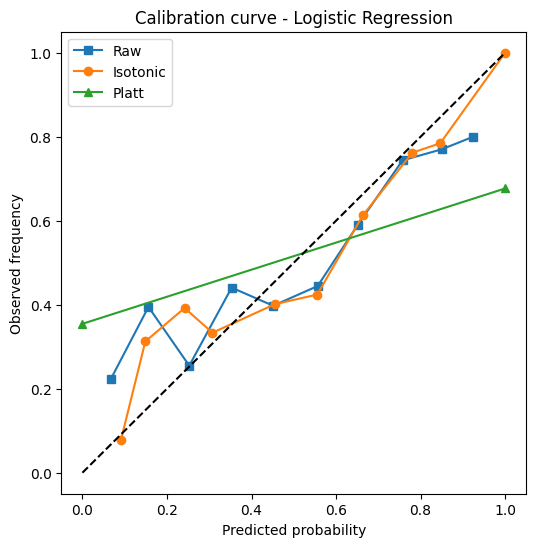

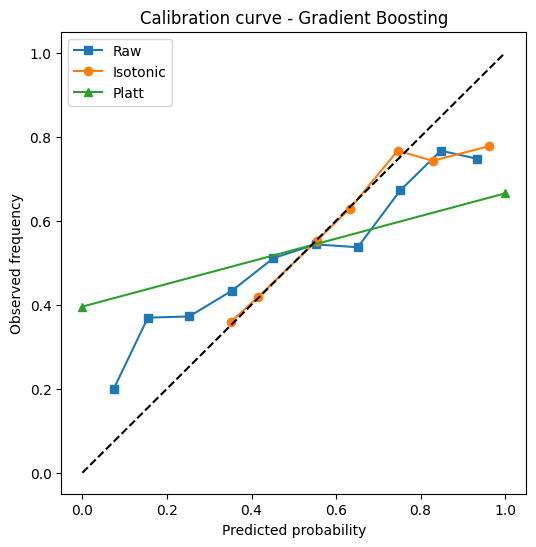

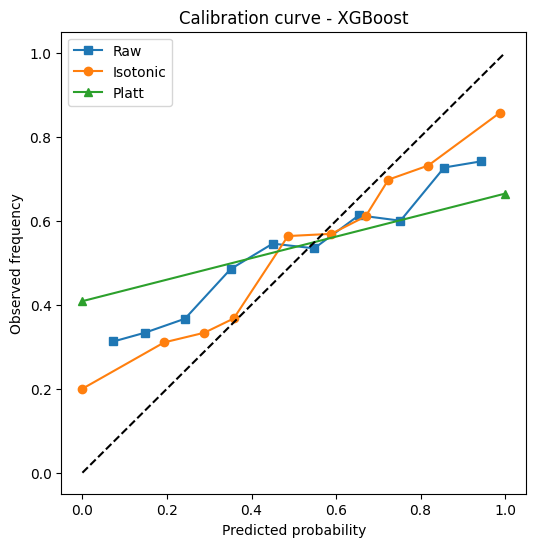

In [7]:
# Calibration curves
figs = plot_calibration_curves(
    models=models,
    calibrated_models=calibrated_models,
    X=X_te_prep,
    y=y_te,
)

for name, fig in figs.items():
    fig.savefig(f"../reports/figures/calibration_curve_{name.replace(' ', '_').lower()}.png")